## Notes for Task 2:
- cv.inRange(image: cv.Mat, min_val: any, max_val: any) --> Returns a binary image with pixels that fall entirely within the min & max values

## Task 2: Find the Duck
If you do not have a webcam or access to a rubber duck, please use the image below instead.
1. Create a new python file and import the OpenCV library.
2. Create a capture object that is connected to a camera on your computer and write a while
true loop that can iterate through the capture object's frames. If you do not have a webcam,
read the image into a variable using cv.imread().
3. Use cv.inRange() to create a threshold for the duck. Have INSERT MIN as the min_val
and INSERT MAX as the max_val if using your webcam. If you are thresholding the giant
duck image, have (15, 100, 100) as the min_val and (35, 255, 255) as the max_val.
4. Try changing the saturation and value for min_val and max_val and see what happens.

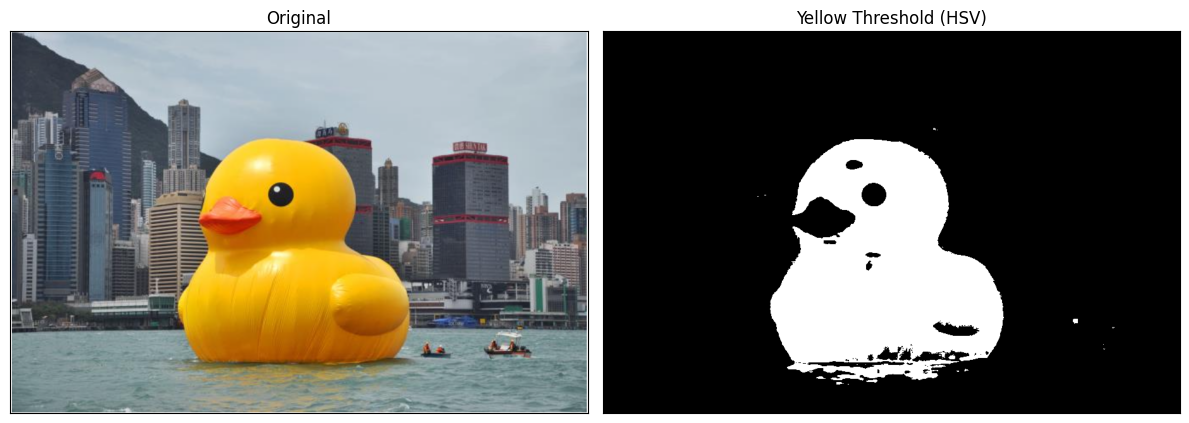

In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt

# Reading the duck image
img = cv.imread("FASTR_Duck.png")
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Convert from BGR to HSV colour space for thresholding
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

# Define the yellow colour range in HSV
# Hue 15-35 captures yellow, Saturation 100-255, Value 100-255
min_val = (15, 100, 100)
max_val = (35, 255, 255)

# Create a binary mask, white where yellow is detected, black everywhere else
mask = cv.inRange(hsv, min_val, max_val)

# Display original and threshold side by side
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.xticks([])
plt.yticks([])

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Yellow Threshold (HSV)")
plt.xticks([])
plt.yticks([])

plt.tight_layout()
plt.show()

## Notes for Task 3:
- cv.getStructuringElement(shape: int, size: tuple) --> Shape structure 
- cv.erode(image: cv.Mat, kernel: np.ndarray) --> Performs an erosion opertaion on the provided image
- cv.dilate(image: cv.Mat, kernel: np.ndarray) --> Performs a dilation operation on the provided image
- cv.morphologyEx(image: cv.Mat, operation: int, kernel) --> Performs a closing or opening operation

## Task 3: Cleaning the Beach
1. Download the image below and find an appropriate HSV colour range for the sand, either
inspecting the pixels using Matplotlib or using the following website:
https://pinetools.com/image-color-picker
Keep in mind the differences between standard HSV and OpenCV HSV.
2. Create a threshold of the sand using cv.inRange(). Check if the threshold is good enough,
if it is not, adjust the HSV range.
3. Once your threshold somewhat resembles the sand threshold on page 6, apply two
opening operations using cv.morphologyEx().

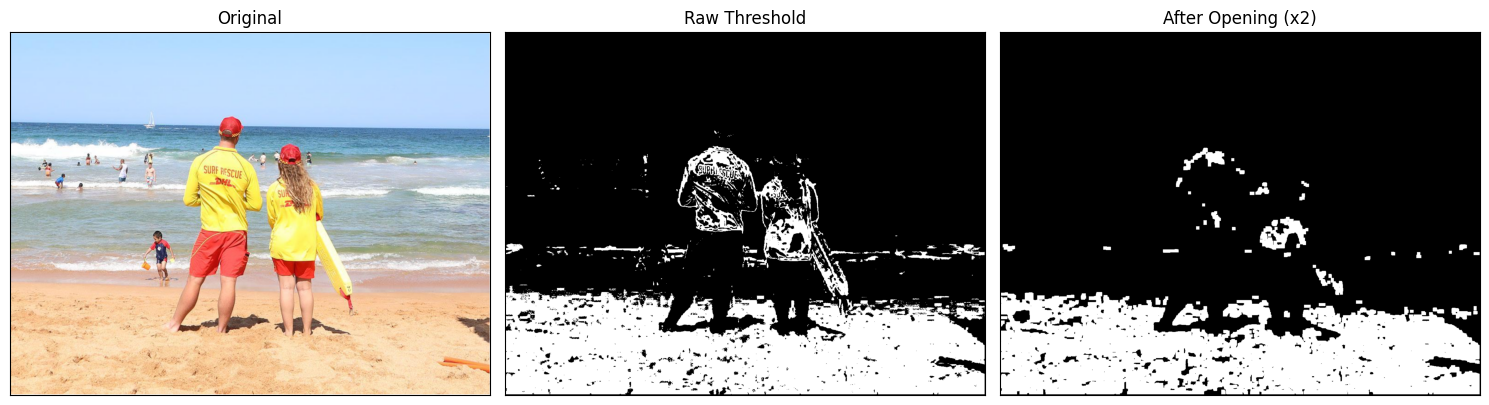

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Read the beach image
img = cv.imread("FASTR_Beach.png")
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Convert to HSV for colour thresholding
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

# HSV range for dry sand (adjust if needed)
# Hue ~15-30 (sandy yellow), Saturation 30-150, Value 100-255
min_val = (15, 30, 100)
max_val = (30, 150, 255)

# Create binary mask for the sand
mask = cv.inRange(hsv, min_val, max_val)

# Create a structuring element (kernel) for morphological operations
kernel = cv.getStructuringElement(cv.MORPH_RECT, (5, 5))

# Apply two opening operations to remove noise
cleaned = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel, iterations=2)

# Display original, raw threshold, and cleaned threshold
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.xticks([])
plt.yticks([])

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Raw Threshold")
plt.xticks([])
plt.yticks([])

plt.subplot(1, 3, 3)
plt.imshow(cleaned, cmap="gray")
plt.title("After Opening (x2)")
plt.xticks([])
plt.yticks([])

plt.tight_layout()
plt.show()